# Titanic Survival Prediction — Logistic Regression :
1. **Problem Statement:**

- The Titanic ship sank in 1912, and out of everyone on board, some people survived and some didn't.

- We have a dataset of passengers with details like their age, gender, ticket class, fare paid, etc.

- Our goal: Build a model that looks at a passenger's details and predicts whether they would have survived (1) or not survived (0).

- This is called a Classification Problem because we are predicting a category (Survived or Not), not a number.

- We will use Logistic Regression — a simple and popular algorithm used for these "Yes/No" type predictions.

## Titanic Dataset — Column Meanings (Easy Words)

- **PassengerId** — Just a number to identify each person. Like a serial number.

- **Survived** — Did the person live or die?
  - `1` = Survived
  - `0` = Did not survive

- **Pclass** — Ticket class (tells us how rich or poor the person was):
  - `1` = Upper class (richest)
  - `2` = Middle class
  - `3` = Lower class (cheapest tickets)

- **Name** — Full name of the person.

- **Sex** — Male or Female.

- **Age** — Age of the person in years.

- **SibSp** — Number of siblings (brothers/sisters) or spouse (husband/wife) traveling with them.

- **Parch** — Number of parents or children traveling with them.

- **Ticket** — The ticket number.

- **Fare** — How much money the person paid for the ticket.

- **Cabin** — Room number on the ship. Many values are missing here.

- **Embarked** — Which port the person boarded the ship from:
  - `C` = Cherbourg
  - `Q` = Queenstown
  - `S` = Southampton

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Loading the dataset

In [4]:
Df=pd.read_csv(r"D:\practice files\train.csv")

In [5]:
print("Shape:", Df.shape)
display(Df.head())

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#  Keep a raw copy:
- Never overwrite the original dataset during cleaning. This lets us compare raw and cleaned versions.

In [6]:
raw_df = Df.copy()
df = Df.copy()

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Data cleaning

In [8]:
# 4. Standardize column names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist()) # Convert all column names to a consistent format (e.g., lowercase, replace spaces with underscores)

['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


In [9]:
# 5. Inspect object/category columns before cleaning

object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    print(f"\n--- {col} ---")
    print(df[col].astype(str).value_counts(dropna=False).head(15))


--- name ---
name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
Moran, Mr. James                                       1
McCarthy, Mr. Timothy J                                1
Palsson, Master. Gosta Leonard                         1
Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)      1
Nasser, Mrs. Nicholas (Adele Achem)                    1
Sandstrom, Miss. Marguerite Rut                        1
Bonnell, Miss. Elizabeth                               1
Saundercock, Mr. William Henry                         1
Andersson, Mr. Anders Johan                            1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Name: count, dtype: int64

--- sex ---
sex
male      577
female    314
Name: count, dtype: int64

--- ticket ---
ticket
347082

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  cabin        204 non-null    str    
 11  embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [11]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64


In [12]:
print( df["survived"].value_counts(normalize=True))

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**info() shows column types and counts. isnull().sum() shows which columns have missing data (Age, Cabin, Embarked). The survival rate tells us the classes are a bit imbalanced (more people died than survived) — good to know before we evaluate later.**

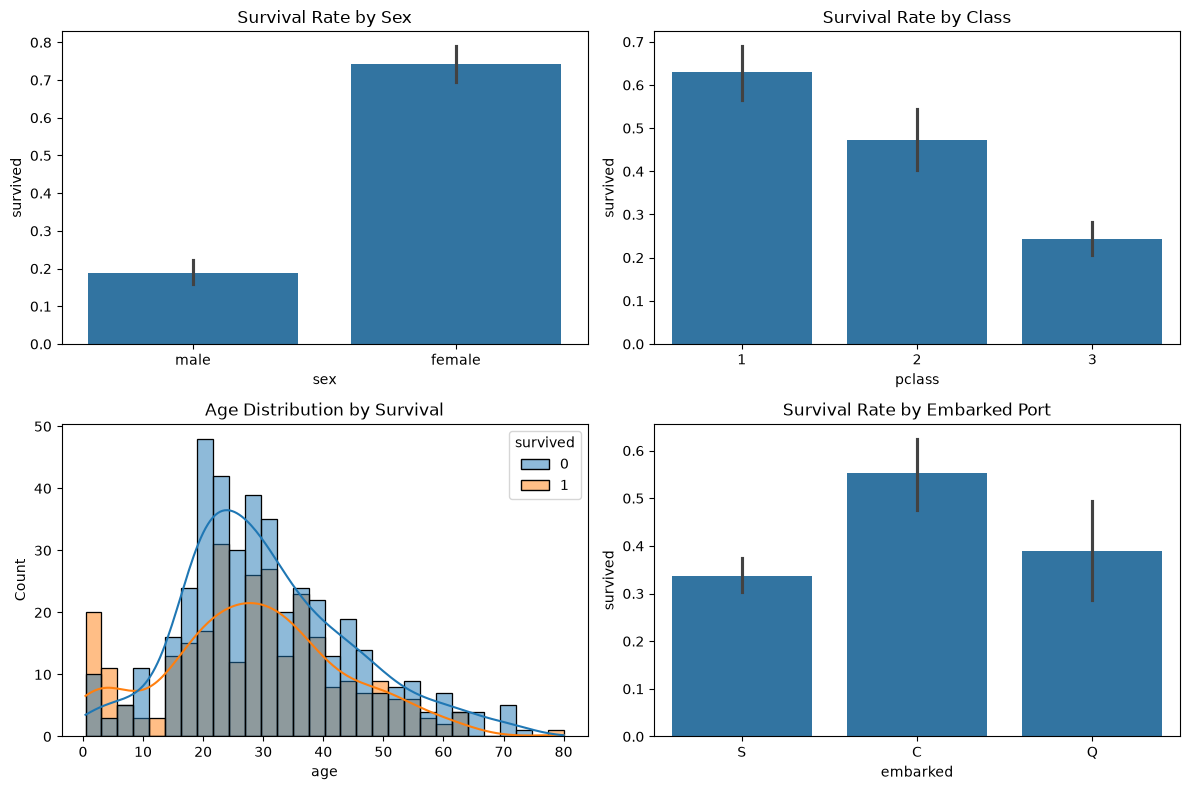

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=df, x="sex", y="survived", ax=axes[0,0])
axes[0,0].set_title("Survival Rate by Sex")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[0,1])
axes[0,1].set_title("Survival Rate by Class")

sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age Distribution by Survival")

sns.barplot(data=df, x="embarked", y="survived", ax=axes[1,1])
axes[1,1].set_title("Survival Rate by Embarked Port")

plt.tight_layout()
plt.show()

**Pictures help us understand patterns faster than numbers. You'll typically see: women survived much more than men, 1st class survived more than 3rd class, and younger children had a slightly better survival chance. This confirms the "women and children first" idea.**

# Feature Engineering (Fixed-Rule — Safe Before Split):

In [14]:
df["name"].sample(25)

787                        Rice, Master. George Hugh
390                       Carter, Mr. William Ernest
633                    Parr, Mr. William Henry Marsh
76                                 Staneff, Mr. Ivan
467                       Smart, Mr. John Montgomery
568                              Doharr, Mr. Tannous
720                Harper, Miss. Annie Jessie "Nina"
537                              LeRoy, Miss. Bertha
651                              Doling, Miss. Elsie
761                   Nirva, Mr. Iisakki Antino Aijo
119                Andersson, Miss. Ellis Anna Maria
338                            Dahl, Mr. Karl Edwart
210                                   Ali, Mr. Ahmed
23                      Sloper, Mr. William Thompson
570                               Harris, Mr. George
365                   Adahl, Mr. Mauritz Nils Martin
748                        Marvin, Mr. Daniel Warner
324                         Sage, Mr. George John Jr
201                              Sage, Mr. Fre

In [16]:
# Extract Title from Name (Mr, Mrs, Miss, etc.) - a genuinely useful signal
df["Title"] = df["name"].str.extract(r",\s*([^\.]*)\.")    # text between , and .
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

# Combine SibSp + Parch into one "FamilySize" feature:
df["FamilySize"] = df["sibsp"] + df["parch"] + 1

# Flag whether the passenger was traveling alone:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Now drop columns we no longer need:
df = df.drop(columns=["passengerid", "name", "ticket", "cabin", "sibsp", "parch"])

df.head()

,survived,pclass,sex,age,fare,embarked,Title,FamilySize,IsAlone
0,0,3,male,22.0,7.2500,S,Mr,2,0
1,1,1,female,38.0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,7.9250,S,Miss,1,1
3,1,1,female,35.0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,8.0500,S,Mr,1,1


# Separate Features (X) and Target (y)

In [18]:
X = df.drop(columns=["survived"])
y = df["survived"]

# Train-Test Split (BEFORE Any Missing-Value Handling or Scaling)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 8)
Test shape: (179, 8)


**This is the most important step for avoiding leakage. We split before filling missing Age or Embarked values, and before scaling anything. stratify=y keeps the survival ratio consistent in both sets. From this point on, X_test/y_test are locked away and untouched until the final evaluation.**

# Identify the column names:

In [20]:
numeric_features = ["age", "fare", "FamilySize"]
categorical_features = ["pclass", "sex", "embarked", "Title", "IsAlone"]

# Build the Preprocessing Pipeline (Imputation Happens Here — AFTER split):

In [23]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
# Pipeline = perform preprocessing steps in order:

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# OneHotEncoder = convert categories into 0/1 columns
# handle_unknown="ignore" = don't give error for unseen categories

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# ColumnTransformer = apply different preprocessing to different columns
# num → numerical pipeline
# cat → categorical pipeline

**This is where missing values actually get handled — but notice, nothing has been "fit" yet, we're just building the recipe. SimpleImputer(strategy="median") will later calculate the median Age using ONLY training data. Same for the most common Embarked port. Scaling (StandardScaler) also only learns mean/std from training data. This is the textbook-correct way to avoid leakage.**

# Build the Full Model Pipeline

In [24]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

**This bundles cleaning + scaling + encoding + the model into ONE single object. Every time we call .fit() on this, all the "learning" steps automatically use only the data we hand it — this structurally prevents leakage.**

# Cross-Validation on Training Data (Sanity Check Before Tuning):

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean().round(4))
print("Std CV accuracy:", cv_scores.std().round(4))

Cross-validation accuracy scores: [0.81818182 0.81118881 0.84507042 0.79577465 0.83802817]
Mean CV accuracy: 0.8216
Std CV accuracy: 0.0179


**Low Std → Model performance is relatively stable.**

**Instead of trusting just ONE train/validation split, cross-validation splits the training data into 5 mini train/test folds, trains and checks 5 times, and averages the result. This gives a much more reliable idea of how good our model really is, and it's all still done using ONLY the training set — the real test set is still untouched.**

In [26]:
# StratifiedKFold → divides data into folds while preserving class ratio
# n_splits=5 → creates 5 folds
# shuffle=True → randomly shuffle data before splitting
# random_state=42 → makes results reproducible

# cross_val_score() → evaluates model using cross-validation
# scoring="accuracy" → uses accuracy as evaluation metric

# Mean CV accuracy → average model performance
# Std CV accuracy → how consistent/stable the model is

# Hyperparameter Tuning with GridSearchCV

In [27]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

grid_search = GridSearchCV(
    model_pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_.round(4))

best_model = grid_search.best_estimator_

Best parameters: {'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV accuracy: 0.8231


**Hyperparameter Tuning-** We give the model different settings and let it find the best combination automatically.

In [28]:
# Hyperparameter Tuning = finding the best model settings

# param_grid → parameters and values to test
# GridSearchCV → tries every parameter combination
# cv → evaluates each combination using cross-validation
# scoring → metric used to compare models
# best_params_ → best parameter combination
# best_score_ → best CV score
# best_estimator_ → complete best model/pipeline
# n_jobs=-1 → use all CPU cores

# Final Training

In [29]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['pclass','sex','age',...,'Title','FamilySize','IsAlone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

In [33]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

- This is the very first time the test set is used for anything. The model applies everything it learned (median Age, most common port, scaling numbers, best C value, and survival patterns) — all learned from training data — onto this brand-new data, and makes predictions.

# evaluate the model 

Test Accuracy: 0.838
Test ROC-AUC: 0.8752

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



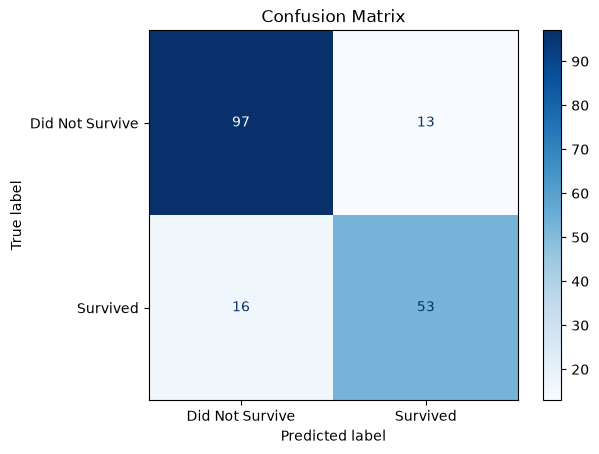

In [35]:
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    cm,
    display_labels=["Did Not Survive", "Survived"]
).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [36]:
# Accuracy → overall percentage of correct predictions

# ROC-AUC → ability to separate Class 0 and Class 1
# 0.5 = random guessing
# 1.0 = perfect separation

# Classification Report → Precision, Recall, F1, Support

# Confusion Matrix → shows exactly correct vs wrong predictions
# TP = correctly predicted positive
# TN = correctly predicted negative
# FP = false positive
# FN = false negative

# ROC curve

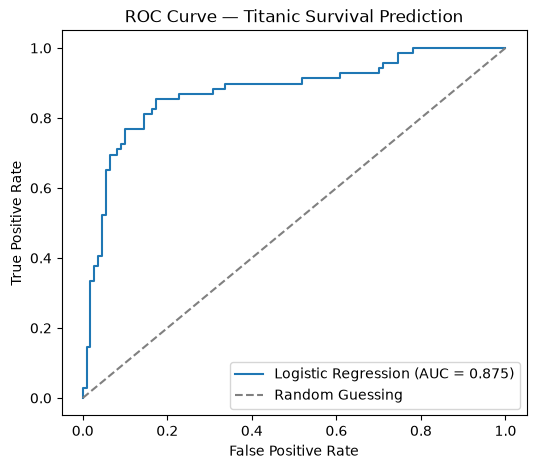

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Titanic Survival Prediction")
plt.legend()
plt.show()

In [38]:
# ROC Curve → shows how well the model separates the two classes
# X-axis (False Positive Rate) → wrong positive predictions
# Y-axis (True Positive Rate) → correctly identified positives
# Dashed line → random guessing (AUC = 0.5)
# Curve above dashed line → model is better than random guessing
# AUC = 0.875 → model has good ability to distinguish survivors vs non-survivors
# AUC closer to 1 → better model

# Titanic Survival Prediction — Project Report (Point-Wise)

## Project Title
**Predicting Titanic Passenger Survival Using Logistic Regression**

---

## 1. What We Were Trying to Solve
- We wanted to answer a simple question: **based on a passenger's basic details (age, gender, class, fare, family size, etc.), can we predict if they survived the Titanic disaster?**
- This is a classic **binary classification** problem — the answer is either "Survived" or "Did Not Survive."
- We treated it like a real, professional project — not just a quick one-shot model.

---

## 2. How We Explored the Data
- Checked the dataset structure, column types, and how many values were missing (mainly in Age, Cabin, Embarked).
- Checked the survival split — noticed more people died than survived (an imbalance worth remembering later).
- Made charts to see patterns before touching the data:
  - **Women survived far more than men.**
  - **1st class passengers survived more than 3rd class.**
  - **Younger children had a slightly better survival chance.**
- These charts confirmed the real Titanic story: *"women and children first."*

---

## 3. Feature Engineering (Creating Smarter Columns)
- Extracted **Title** (Mr, Mrs, Miss, Master, Rare) from the Name column — titles hint at age, gender, and social status.
- Combined **SibSp + Parch** into one new column called **FamilySize**.
- Created an **IsAlone** flag to mark passengers traveling solo.
- Dropped columns that don't help prediction: PassengerId, Name, Ticket, Cabin.
- All of this was done using fixed rules — no statistics calculated from the data — so it was safe to do before splitting.

---

## 4. Avoiding Data Leakage (Most Important Discipline)
- **Split the data into training and test sets FIRST**, before doing anything that "learns" from the data.
- Only AFTER splitting did we:
  - Fill missing **Age** with the median (calculated only from training data).
  - Fill missing **Embarked** with the most common port (calculated only from training data).
  - Scale numeric columns and encode categorical columns — again, learned only from training data.
- All of this was wrapped inside a single **Pipeline**, so nothing could accidentally "peek" at the test data.
- This mirrors real life: you can't use future/unseen data to build your rules in advance.

---

## 5. Building and Tuning the Model
- Used **Logistic Regression** as our prediction algorithm (good fit for Yes/No problems).
- Used **5-fold Cross-Validation** on the training data to get a reliable performance estimate (instead of trusting just one split).
- Used **GridSearchCV** to systematically test different model settings (regularization strength) and pick the best one.
- All tuning was done strictly on training data — the test set stayed untouched throughout this whole process.

---

## 6. Final Evaluation (First Time Touching the Test Set)
- Only after tuning did we use the test set — for the very first time — to check real-world performance.
- We looked at multiple metrics, not just accuracy:
  - **Accuracy** — overall percentage of correct predictions.
  - **ROC-AUC Score** — how well the model separates survivors from non-survivors.
  - **Confusion Matrix** — a breakdown of correct vs incorrect predictions for each class.
  - **Precision & Recall** — since missing a real survivor and wrongly predicting a survivor both matter, but differently.

---

## 7. Key Findings
- **Being female** was the strongest predictor of survival.
- **Traveling in 1st class** significantly increased survival chances.
- **Being an adult male, especially in 3rd class**, was the strongest predictor of *not* surviving.
- These results matched real historical Titanic evacuation patterns.

---

## 8. What This Project Demonstrates
- A complete, trustworthy machine learning workflow, not just a "get an accuracy number" exercise.
- Key skills shown:
  - Honest, visual data exploration
  - Thoughtful feature engineering
  - Leakage-free preprocessing pipeline
  - Proper cross-validation
  - Systematic hyperparameter tuning
  - Well-rounded final evaluation
- These same principles apply beyond Titanic — to real-world, high-stakes problems like medical diagnosis or credit risk prediction.